# Similar Region Statistics

This notebook is for analyzing the similar region annotations and to get some statistics

In [17]:
%load_ext autoreload
%autoreload 2

import sys
import json
import math
import csv
from pathlib import Path
from collections import defaultdict
import random

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

from IPython.display import Audio, display, YouTubeVideo, HTML

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# You need the csv file
csv_path = Path("/home/raraz/data/dvi-similar-regions/Discogs-VI-SIREN/train/similar-regions.csv")
# csv_path = Path("/home/raraz/data/dvi-similar-regions/Discogs-VI-SIREN/val/similar-regions.csv")

In [3]:
def yt_iframe(video_id, start=0, aspect="16/9"):
    return (f'<div style="position:relative; width:100%; aspect-ratio:{aspect};">'
            f'<iframe style="position:absolute; inset:0; width:100%; height:100%; border:0;" '
            f'src="https://www.youtube.com/embed/{video_id}?start={start}" '
            f'allowfullscreen></iframe></div>')


def display_row_yt(row):
    def _scalar(row, col):
        v = row[col]
        return v.item() if hasattr(v, "item") else v

    display(row)
    panels = []
    for i in (0, 1):
        yt_id = _scalar(row, f"youtube_id{i}")
        start = int(round(float(_scalar(row, f"hole_v{i}_start"))))
        panels.append(f'<div style="flex:1; min-width:0;">{yt_iframe(yt_id, start)}</div>')
    display(HTML(
        f'<div style="display:flex; gap:12px; margin:8px 0; width:100%;">'
        f'{"".join(panels)}</div>'
    ))

## Load the csv

In [4]:
# This is a very large file, you need to choose which fields to load in order to fit it to memory 
# or you can use float16 for some fields
COLUMN_DTYPES = {
    "clique_id": "object",
    "version_id0": "object",
    "version_id1": "object",
    "youtube_id0": "object",
    "youtube_id1": "object",
    "duration0": "float32",
    "duration1": "float32",
    "segment_duration": "float32",
    "hole_v0_start": "float32",
    "hole_v1_start": "float32",
    "hole_height": "float32",
    "k": "int16",
    "basin_area": "int32",
}

df = pd.read_csv(csv_path, usecols=list(COLUMN_DTYPES.keys()), dtype=COLUMN_DTYPES)
print(f"{len(df):,}")
display(df.head())

96,754,487


,clique_id,version_id0,version_id1,youtube_id0,youtube_id1,duration0,duration1,segment_duration,k,hole_height,hole_v0_start,hole_v1_start,basin_area
0,C-0012736,V-0113562,V-0113620,-1Fe2OCHzcs,My1_VxhMUl4,163.5,118.5,20.0,0,1.741,11.0,9.0,107
1,C-0012736,V-0113562,V-0113620,-1Fe2OCHzcs,My1_VxhMUl4,163.5,118.5,20.0,1,1.860,19.0,9.0,11
2,C-0012736,V-0113562,V-0113620,-1Fe2OCHzcs,My1_VxhMUl4,163.5,118.5,20.0,2,1.868,43.0,9.0,4
3,C-0012736,V-0113562,V-0113620,-1Fe2OCHzcs,My1_VxhMUl4,163.5,118.5,20.0,3,1.875,41.0,9.0,15
4,C-0012736,V-0113562,V-0113620,-1Fe2OCHzcs,My1_VxhMUl4,163.5,118.5,20.0,4,1.877,33.0,13.0,4


In [5]:
# # Remove Duplicates
# df = df[df['hole_height'] > 1e-2]
# print(f"{len(df):,}")

In [18]:
row = df.sample(n=1)

display_row_yt(row)

# If you have the audio files available, check the bottom of this notebook
# display_hole(row)

,clique_id,version_id0,version_id1,youtube_id0,youtube_id1,duration0,duration1,segment_duration,k,hole_height,hole_v0_start,hole_v1_start,basin_area
11497856,C-0050843,V-0466009,V-0466278,nd7gE9Mzx0I,fU9izT3QL_o,196.0,268.799988,20.0,11,0.069,136.0,199.0,132


## Statistics

In [6]:
# Cliques that survive the similar region finding algorithm
df_track_clique_ids = set(df["clique_id"].to_list())
print(f'{len(df_track_clique_ids):,}')

# Number of total versions
print(f'{pd.unique(df[["version_id0", "version_id1"]].values.ravel()).size:,}')

# unique version pairs
pairs = np.sort(df[["version_id0", "version_id1"]].to_numpy(dtype=str), axis=1)
n_unique = len(np.unique(pairs, axis=0))
print(f"{n_unique:,}")

73,887
317,709
3,112,157


### Hole Height

In [7]:
df["hole_height"].describe(percentiles=[i/10 for i in range(11)])

count    9.675449e+07
mean     6.303921e-01
std      4.876665e-01
min      0.000000e+00
0%       0.000000e+00
10%      1.060000e-01
20%      1.900000e-01
30%      2.870000e-01
40%      3.890000e-01
50%      5.010000e-01
60%      6.330000e-01
70%      8.040000e-01
80%      1.038000e+00
90%      1.392000e+00
100%     2.000000e+00
max      2.000000e+00
Name: hole_height, dtype: float64

#### Small Distance Pairs

In [8]:
# Pairs that are possibly duplicates (adjust threshold as needed)
df_small_nonzero = df[df['hole_height'] < 1e-1]
print(len(df_small_nonzero))
print(100*len(df_small_nonzero)/len(df))

8752680
9.046278132816724


### k

In [9]:
df["k"].describe()

count    9.675449e+07
mean     1.861294e+01
std      1.327581e+01
min      0.000000e+00
25%      7.000000e+00
50%      1.600000e+01
75%      2.800000e+01
max      4.900000e+01
Name: k, dtype: float64

In [10]:
print(f'{len(df):>10,}')
print(f'{len(df[df["k"] < 10]):>10,}')
print(f'{len(df[df["k"] < 7]):>10,}')
print(f'{len(df[df["k"] < 5]):>10,}')
print(f'{len(df[df["k"] < 3]):>10,}')
print(f'{len(df[df["k"] < 1]):>10,}')

96,754,487
30,245,537
21,455,658
15,424,721
 9,300,494
 3,112,157


### Basin Area

In [11]:
for a in [2, 3, 4, 5, 6]:
    print(f'{a} < {100 * len(df[df["basin_area"] > a]) / len(df):.1f}')

2 < 82.3
3 < 72.9
4 < 66.5
5 < 62.1
6 < 58.4


In [12]:
df_small_basin = df[df["basin_area"] == 6].sort_values('hole_height', ascending=False)
# df_small_basin = df[df["basin_area"].between(1, 2, inclusive="right")]
print(len(df_small_basin))

df_small_basin.head()

3495792


,clique_id,version_id0,version_id1,youtube_id0,youtube_id1,duration0,duration1,segment_duration,k,hole_height,hole_v0_start,hole_v1_start,basin_area
2928076,C-0006521,V-0061439,V-0061624,16-TNPyyKE0,SXWD2yYwsxM,388.100006,150.600006,20.0,33,1.992,294.0,87.0,6
82253039,C-0037910,V-0350368,V-0350379,_XLrb0wPwgQ,OC5Xg0qnm_0,91.800003,187.399994,20.0,27,1.991,57.0,50.0,6
26071170,C-0065482,V-0673225,V-0673740,YpLmY5ItDd8,LM6dy3w0Ids,180.300003,208.800003,20.0,49,1.991,42.0,42.0,6
82428183,C-0001252,V-0012258,V-0012288,98alaMISQWM,oHBohzpDlrk,438.200012,215.300003,20.0,18,1.990,262.0,22.0,6
67996231,C-0007937,V-0071820,V-0071908,jFFj2rqoXhI,1UkspIz0X0w,284.399994,200.800003,20.0,8,1.990,2.0,6.0,6


## Plots

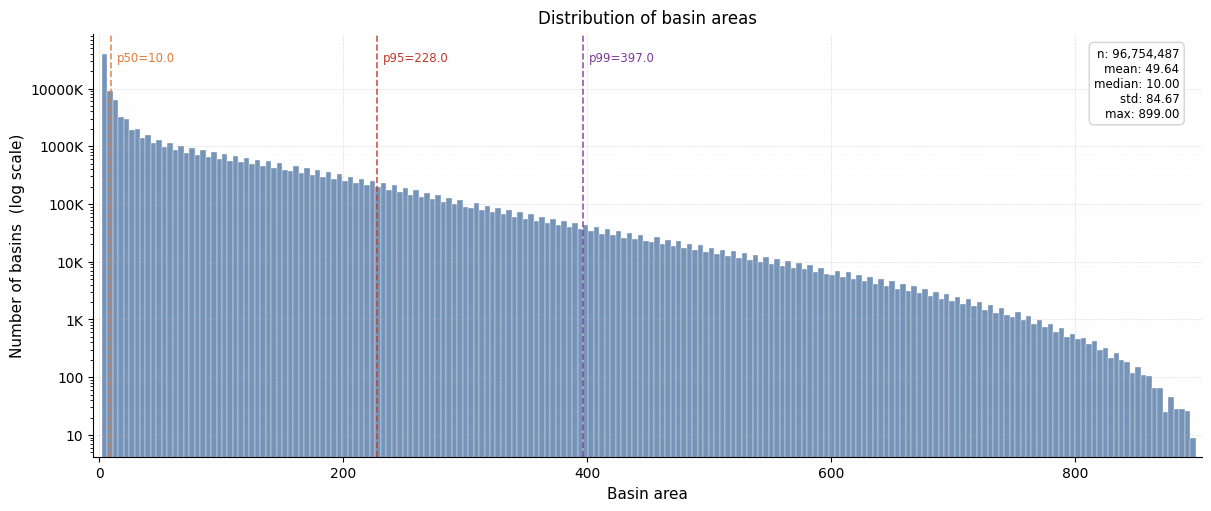

In [13]:
data = df["basin_area"].dropna()

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

ax.hist(
    data,
    bins=200,
    color="#5e81ac",
    edgecolor="white",
    linewidth=0.3,
    alpha=0.85,
    log=True,
)

ax.set_xlim(-5, data.max() + 5)

for p, label, color in [
    (50,  "p50", "#e07b39"),
    (95,  "p95", "#c0392b"),
    (99,  "p99", "#7d3c98"),
]:
    val = np.percentile(data, p)
    ax.axvline(val, color=color, linewidth=1.2, linestyle="--", alpha=0.85)
    ax.text(
        val + data.max() * 0.005, ax.get_ylim()[1] * 0.5,
        f"{label}={val:,.1f}",
        color=color, fontsize=8.5, va="top",
    )

ax.set_xlabel("Basin area", fontsize=11)
ax.set_ylabel("Number of basins  (log scale)", fontsize=11)
ax.set_title("Distribution of basin areas", fontsize=12, pad=8)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{x:,.0f}"
))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, _: f"{int(y):,}" if y < 1000 else f"{y/1000:.0f}K"
))

ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.5)
ax.grid(True, which="minor", linestyle=":", linewidth=0.2, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

stats_text = (
    f"n: {len(data):,}\n"
    f"mean: {data.mean():,.2f}\n"
    f"median: {data.median():,.2f}\n"
    f"std: {data.std():,.2f}\n"
    f"max: {data.max():,.2f}"
)
ax.text(
    0.98, 0.97, stats_text,
    transform=ax.transAxes, fontsize=8.5,
    va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.85),
)

# plt.savefig("basin_area_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Number of regions per clique

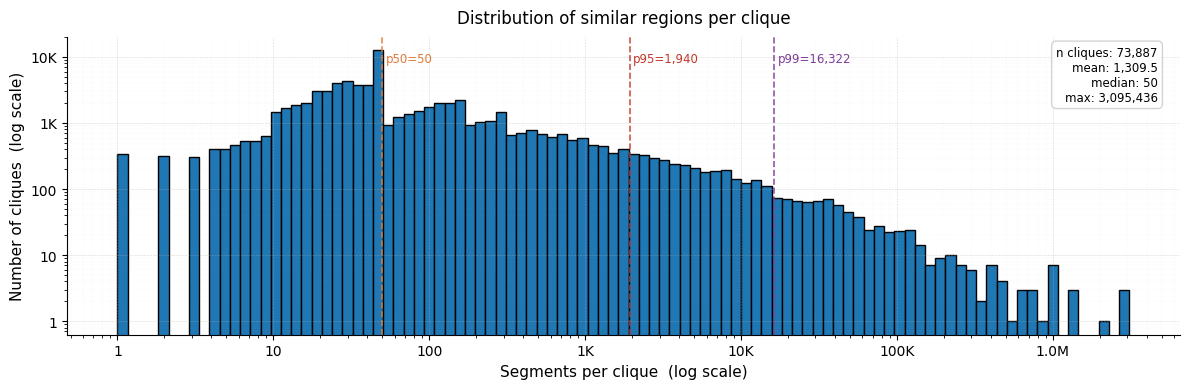

In [14]:
counts = df.groupby("clique_id").size()

fig, ax = plt.subplots(figsize=(12, 4))
n, bins, patches = ax.hist(
    counts,
    bins=np.logspace(np.log10(counts.min()), np.log10(counts.max()), 100),
    edgecolor="black",
)

ax.set_xscale("log")
ax.set_yscale("log")

# Percentile markers
for p, label, color in [
    (50,  "p50",  "#e07b39"),
    (95,  "p95",  "#c0392b"),
    (99,  "p99",  "#7d3c98"),
]:
    val = np.percentile(counts, p)
    ax.axvline(val, color=color, linewidth=1.2, linestyle="--", alpha=0.85)
    ax.text(
        val * 1.05, ax.get_ylim()[1] * 0.6,
        f"{label}={val:,.0f}",
        color=color, fontsize=8.5, va="top",
    )

# Axis labels & formatting
ax.set_xlabel("Segments per clique  (log scale)", fontsize=11)
ax.set_ylabel("Number of cliques  (log scale)", fontsize=11)
ax.set_title("Distribution of similar regions per clique", fontsize=12, pad=10)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x):,}" if x < 1000 else f"{x/1000:.0f}K" if x < 1e6 else f"{x/1e6:.1f}M"
))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, _: f"{int(y):,}" if y < 1000 else f"{y/1000:.0f}K"
))

ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.5)
ax.grid(True, which="minor", linestyle=":", linewidth=0.2, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# Summary stats box
stats_text = (
    f"n cliques: {len(counts):,}\n"
    f"mean: {counts.mean():,.1f}\n"
    f"median: {counts.median():,.0f}\n"
    f"max: {counts.max():,}"
)
ax.text(
    0.98, 0.97, stats_text,
    transform=ax.transAxes, fontsize=8.5,
    va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.85),
)

plt.tight_layout()
# plt.savefig("clique_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

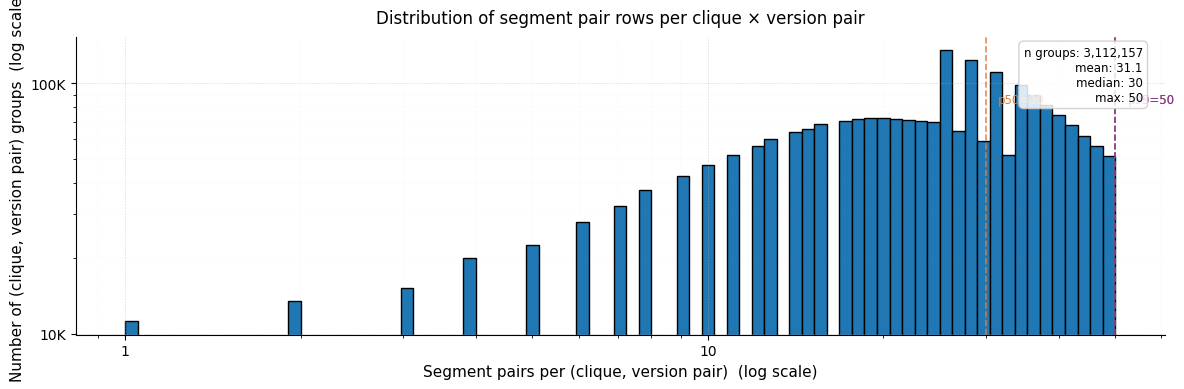

In [15]:
counts = df.groupby(["clique_id", "version_id0", "version_id1"]).size()

fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(
    counts,
    bins=np.logspace(np.log10(counts.min()), np.log10(counts.max()), 80),
#     color="#2a9d8f",
    edgecolor="black",
#     linewidth=0.3,
#     alpha=0.85,
)

ax.set_xscale("log")
ax.set_yscale("log")

for p, label, color in [
    (50,  "p50", "#e07b39"),
    (95,  "p95", "#c0392b"),
    (99,  "p99", "#7d3c98"),
]:
    val = np.percentile(counts, p)
    ax.axvline(val, color=color, linewidth=1.2, linestyle="--", alpha=0.85)
    ax.text(
        val * 1.05, ax.get_ylim()[1] * 0.6,
        f"{label}={val:,.0f}",
        color=color, fontsize=8.5, va="top",
    )

ax.set_xlabel("Segment pairs per (clique, version pair)  (log scale)", fontsize=11)
ax.set_ylabel("Number of (clique, version pair) groups  (log scale)", fontsize=11)
ax.set_title("Distribution of segment pair rows per clique × version pair", fontsize=12, pad=10)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x):,}" if x < 1000 else f"{x/1000:.0f}K" if x < 1e6 else f"{x/1e6:.1f}M"
))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda y, _: f"{int(y):,}" if y < 1000 else f"{y/1000:.0f}K"
))

ax.grid(True, which="major", linestyle="--", linewidth=0.4, alpha=0.5)
ax.grid(True, which="minor", linestyle=":", linewidth=0.2, alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

stats_text = (
    f"n groups: {len(counts):,}\n"
    f"mean: {counts.mean():,.1f}\n"
    f"median: {counts.median():,.0f}\n"
    f"max: {counts.max():,}"
)
ax.text(
    0.98, 0.97, stats_text,
    transform=ax.transAxes, fontsize=8.5,
    va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc", alpha=0.85),
)

plt.tight_layout()
# plt.savefig("version_pair_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## If Audio is Available

Uncomment the below cell if you have the audio files available, otherwise the notebook uses the Youtube API.

In [ ]:
# current_dir = Path.cwd()
# parent_dir = current_dir.parent
# if str(parent_dir) not in sys.path:
#     sys.path.append(str(parent_dir))
# print(f"Added {parent_dir} to sys.path")

# music_dir = Path("/projects/mtg/projects/unified-similarity/datasets/discogs-vi-yt-16kHz/audio/")

# from src.common.audio import load_audio, SAMPLE_RATE

# def display_hole(row):

#     print(row["clique_id"].item())

#     yt_id0 = row['youtube_id0'].item()
#     yt_id1 = row['youtube_id1'].item()

#     audio_path0 = music_dir / yt_id0[:2] / f'{yt_id0}.wav'
#     audio_path1 = music_dir / yt_id1[:2] / f'{yt_id1}.wav'
    
#     segment_dur = row["segment_duration"].item()

#     hole_v0_t0 = row["hole_v0_start"].item()
#     hole_v0_t1 = min(hole_v0_t0+segment_dur, row["duration0"].item())
#     print(f"{hole_v0_t0}-{hole_v0_t1}")
#     hole_v1_t0 = row["hole_v1_start"].item()
#     hole_v1_t1 = min(hole_v1_t0+segment_dur, row["duration1"].item())
#     print(f"{hole_v1_t0}-{hole_v1_t1}")

#     audio0 = load_audio(
#         audio_path0, start=int(hole_v0_t0*SAMPLE_RATE), length=int((hole_v0_t1-hole_v0_t0)*SAMPLE_RATE)
#     )
#     audio1 = load_audio(
#         audio_path1, start=int(hole_v1_t0*SAMPLE_RATE), length=int((hole_v1_t1-hole_v1_t0)*SAMPLE_RATE)
#     )

#     display(Audio(audio0, rate=SAMPLE_RATE, normalize=False))
#     display(Audio(audio1, rate=SAMPLE_RATE, normalize=False))